In [14]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# install google earth engine 
try:
    ee.Initialize(project='aveiro-coastal-research')
    print("Gee successfully installed")
except Exception as e:
    print(f"gee installation failed: {e}")

Gee successfully installed


In [15]:
# center location of aveiros lagoon 
aveiro_center = ee.Geometry.Point([-8.65, 40.64])

# roi (region of interest) = lagoon + direct coastal area
roi = ee.Geometry.Rectangle([-8.76, 40.55, -8.60, 40.78])

# coordinates for plots in python-dict
ROI_COORDS = {
    'lon_min': -8.76, 'lon_max': -8.60,
    'lat_min': 40.55, 'lat_max': 40.78 
}

print("area defined")
print(f"    Aveiro Lagoon:  {ROI_COORDS['lon_min']}°W to {ROI_COORDS['lon_max']}°W")
print(f"                    {ROI_COORDS['lat_min']}°N to {ROI_COORDS['lat_max']}°N")

area defined
    Aveiro Lagoon:  -8.76°W to -8.6°W
                    40.55°N to 40.78°N


In [16]:
def load_sentinel2(start_date, end_date, roi, max_cloud=5):
    """
    Loading a Sentinel-2 collection for a time frame.
    
    Parameters:
        start_date / end_date : str  – ISO-Date, e.g. '2022-07-01'
        roi                   : ee.Geometry
        max_cloud             : int  – max. cloud percentage
    
    Return:
        ee.Image 
    """
    collection = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(roi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', max_cloud))        
        # SCL-based cloudmass (better than only using the percentage)
        .map(mask_clouds_s2)
    )
    
    count = collection.size().getInfo()
    print(f"  {start_date[:4]}: {count} scenes found")
    
    # median from all scenes - more stable than .first()
    return collection.median().clip(roi)


def mask_clouds_s2(image):
    """
    masks cloud & shadow over the Scene Classification Layer (SCL).
    SCL-classes of importance: 4 (vegetation), 5 (soil), 6 (water)
    """
    scl = image.select('SCL')
    clear = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))
    return image.updateMask(clear)


print("✓ functions defined")
print("  → load_sentinel2() : loading & masking Sentiel-2 data")
print("  → mask_clouds_s2() : SCL-based cloud-mask")

✓ functions defined
  → load_sentinel2() : loading & masking Sentiel-2 data
  → mask_clouds_s2() : SCL-based cloud-mask


In [17]:
# test in summer 2022 (reference-year)
print("Loading test image (summer 2022)...")
img_test = load_sentinel2('2022-06-01', '2022-08-31', roi, max_cloud=5)

# calculate NDWI 
ndwi_test = img_test.normalizedDifference(['B3', 'B8']).rename('NDWI')

# Map
Map = geemap.Map(basemap='SATELLITE')
Map.centerObject(roi, 12)
Map.addLayer(
    img_test, 
    {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500}, 
    'Echtfarbe 2022'
)
Map.addLayer(
    ndwi_test, 
    {'min': -0.3, 'max': 0.5, 'palette': ['#d4a373', '#fff', '#0077b6']}, 
    'NDWI 2022'
)
Map

Loading test image (summer 2022)...
  2022: 21 scenes found


Map(center=[40.664961508881134, -8.679999999998586], controls=(WidgetControl(options=['position', 'transparent…

In [18]:
# JRC Global Surface Water – Version 1.4
jrc = ee.Image('JRC/GSW1_4/GlobalSurfaceWater')

# Ocean mask: pixels which are allways water (>99%) = open ocean
jrc_occurrence = jrc.select('occurrence')
ocean_mask = jrc_occurrence.gte(99)

# 'seasonality' = how many months/years water is present
# value >= 9 means: min. 9 out of 12 months water 
jrc_permanent = jrc.select('seasonality').gte(9).clip(roi)

"""
# Zur Info: alle verfügbaren Bänder ausgeben
# information purpose: alle 
print("JRC Bänder:", jrc.bandNames().getInfo())
"""

# Karte
Map2 = geemap.Map(basemap='SATELLITE')
Map2.centerObject(roi, 12)
Map2.addLayer(
    jrc_permanent.selfMask(),
    {'palette': ['#0077b6']},
    'JRC: permanent water (≥9 months/year)'
)
Map2.addLayer(
    ndwi_test.gt(0.1).selfMask(),
    {'palette': ['#00f5d4']},
    'NDWI > 0.1 (2022)'
)
Map2

Map(center=[40.664961508881134, -8.679999999998586], controls=(WidgetControl(options=['position', 'transparent…

In [19]:
def otsu_threshold(histogram_dict):
    """
    Otsu's Method: Finds the threshold that maximizes variance
    between two classes (water / land)
    
    Works on the Gee histogram output
    """
    histogram = histogram_dict.getInfo()
    
    counts = np.array(histogram['histogram'])
    bin_width = histogram['bucketWidth']
    bin_start = histogram['bucketMin']
    
    # Calculate binomial centers
    bins = bin_start + bin_width * (np.arange(len(counts)) + 0.5)
    
    total = counts.sum()
    
    best_threshold = bins[0]
    best_variance = 0
    
    for i in range(1, len(bins)):
        # Class 1: everything left of the threshold (land)
        w1 = counts[:i].sum() / total
        # Class 2: everything to the right (water)
        w2 = counts[i:].sum() / total
        
        if w1 == 0 or w2 == 0:
            continue
        
        mu1 = (counts[:i] * bins[:i]).sum() / counts[:i].sum()
        mu2 = (counts[i:] * bins[i:]).sum() / counts[i:].sum()
        
        # Between-class variance
        variance = w1 * w2 * (mu1 - mu2) ** 2
        
        if variance > best_variance:
            best_variance = variance
            best_threshold = bins[i]
    
    return best_threshold


def get_otsu_threshold(ndwi_image, roi):
    histogram_dict = ndwi_image.reduceRegion(
        reducer=ee.Reducer.histogram(maxBuckets=200),
        geometry=roi,
        scale=20,
        maxPixels=1e9
    ).get('NDWI')
    
    return otsu_threshold(ee.Dictionary(histogram_dict))


# Test
threshold_2022 = get_otsu_threshold(ndwi_test, roi)
print(f"Otsu-Threshold 2022:       {threshold_2022:.4f}")
print(f"Current fixed value:        0.1000")
print(f"Difference:               {abs(threshold_2022 - 0.1):.4f}")

Otsu-Threshold 2022:       -0.0820
Current fixed value:        0.1000
Difference:               0.1820


In [20]:
# Median of all known Otsu values ​​(2018–2024)
otsu_values = [-0.0117, -0.1445, -0.1500, -0.1500, -0.0820, -0.1500, -0.1055]
fixed_threshold = float(np.median(otsu_values))
print(f"Fixed threshold (Median Otsu): {fixed_threshold:.4f}\n")

years = list(range(2017, 2025))
results = []

print(f"{'Year':<8} {'Threshold':>10} {'Area (ha)':>12} {'Scenes':>8}")
print("-" * 42)

for year in years:
    try:
        # FIX 2017: select() BEFORE the cloud mask – resolves conflict
        collection = (
            ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(roi)
            .filterDate(f'{year}-06-01', f'{year}-08-31')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5))
            # First reduce to common bands, THEN mask
            .map(lambda img: img.select(['B3', 'B8', 'SCL']))
            .map(mask_clouds_s2)
        )

        count = collection.size().getInfo()
        img = collection.median().clip(roi)

        ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')

        water = ndwi.gt(fixed_threshold).rename('water')

        area_ha = (water
                   .multiply(ee.Image.pixelArea())
                   .reduceRegion(
                       reducer=ee.Reducer.sum(),
                       geometry=roi,
                       scale=10,
                       maxPixels=1e9
                   )
                   .get('water'))

        area_ha = ee.Number(area_ha).divide(10000).getInfo()

        results.append({'year': year, 'area_ha': area_ha, 'threshold': fixed_threshold})
        print(f"{year:<8} {fixed_threshold:>10.4f} {area_ha:>12.1f}  ({count} Scenes)")

    except Exception as e:
        print(f"{year:<8} {'Error':>10} – {e}")
        results.append({'year': year, 'area_ha': None, 'threshold': None})

df = pd.DataFrame(results)
print("\n✓ Time series completed")

Fixed threshold (Median Otsu): -0.1445

Year      Threshold    Area (ha)   Scenes
------------------------------------------
2017        -0.1445      10237.8  (23 Scenes)
2018        -0.1445      11415.5  (20 Scenes)
2019        -0.1445      11070.0  (13 Scenes)
2020        -0.1445      10946.3  (22 Scenes)
2021        -0.1445      10794.7  (21 Scenes)
2022        -0.1445      10622.1  (21 Scenes)
2023        -0.1445      10956.0  (33 Scenes)
2024        -0.1445      11205.3  (19 Scenes)

✓ Time series completed


In [21]:
lagoon_polygon = ee.Geometry.Polygon([[
    [-8.700, 40.790],   # North-West
    [-8.590, 40.790],   # North-East
    [-8.590, 40.530],   # South-East
    [-8.640, 40.530],   # South
    [-8.730, 40.555],   # South-West
    [-8.755, 40.600],   # West-South
    [-8.745, 40.650],   # West-Mid
    [-8.738, 40.700],   # West Mid-North
    [-8.720, 40.750],   # Nort-West Mid
    [-8.710, 40.790],   # back to North-West
]])

Map_lagoon2 = geemap.Map(basemap='SATELLITE')
Map_lagoon2.centerObject(lagoon_polygon, 12)
Map_lagoon2.addLayer(
    ocean_mask.selfMask(),
    {'palette': ['#023e8a'], 'opacity': 0.6},
    'Ocean-mask (JRC >99%)'
)
Map_lagoon2.addLayer(
    lagoon_polygon,
    {'color': 'yellow', 'fillColor': '00000000'},
    'Lagoone ROI (Polygon)'
)
Map_lagoon2

Map(center=[40.659678801575964, -8.662255685445693], controls=(WidgetControl(options=['position', 'transparent…

In [22]:
def get_lagoon_water(year, lagoon_polygon, ocean_mask, threshold=fixed_threshold):
    img = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(lagoon_polygon)
           .filterDate(f'{year}-06-01', f'{year}-08-31')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5))
           .map(lambda img: img.select(['B3', 'B8', 'SCL']))
           .map(mask_clouds_s2)
           .median()
           .clip(lagoon_polygon))

    ndwi = img.normalizedDifference(['B3', 'B8'])
    water = ndwi.gt(threshold)

    # Mask out the ocean
    return water.updateMask(ocean_mask.Not())


# Time series, only lagoon
print("calculating lagoone water (without the ocean)...\n")
print(f"{'Year':<8} {'Area (ha)':>12} {'Scenes':>8}")
print("-" * 32)

results_lagoon = []

for year in years:
    try:
        water = get_lagoon_water(year, lagoon_polygon, ocean_mask)

        count = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(lagoon_polygon)
                 .filterDate(f'{year}-06-01', f'{year}-08-31')
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5))
                 .size().getInfo())

        area_ha = (water
                   .multiply(ee.Image.pixelArea())
                   .reduceRegion(
                       reducer=ee.Reducer.sum(),
                       geometry=lagoon_polygon,
                       scale=10,
                       maxPixels=1e9
                   )
                   .get('nd'))

        area_ha = ee.Number(area_ha).divide(10000).getInfo()

        results_lagoon.append({'year': year, 'area_ha': area_ha})
        print(f"{year:<8} {area_ha:>12.1f}  ({count} Scenes)")

    except Exception as e:
        print(f"{year:<8} {'Error':>10} – {e}")
        results_lagoon.append({'year': year, 'area_ha': None})

df_lagoon = pd.DataFrame(results_lagoon)
print("\n✓ Lagoone time series completed")

calculating lagoone water (without the ocean)...

Year        Area (ha)   Scenes
--------------------------------
2017           4655.0  (23 Scenes)
2018           5999.6  (20 Scenes)
2019           5416.3  (13 Scenes)
2020           5490.6  (22 Scenes)
2021           5354.1  (21 Scenes)
2022           5174.1  (21 Scenes)
2023           5390.2  (33 Scenes)
2024           5682.2  (19 Scenes)

✓ Lagoone time series completed


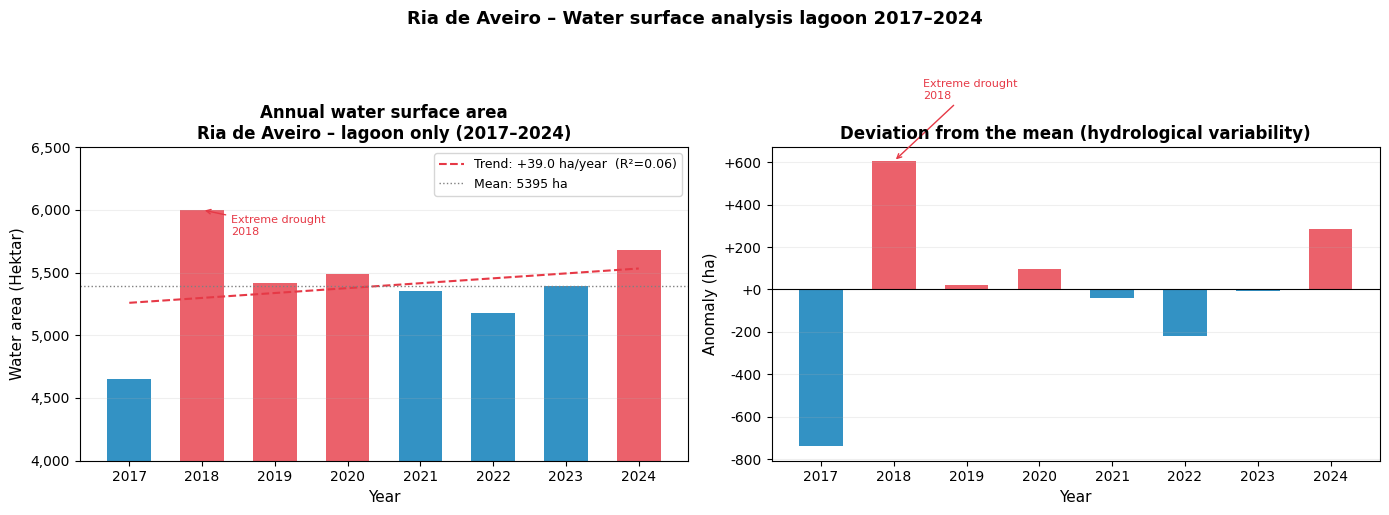


Mean:          5395 ha
Min:             4655 ha (2017)
Max:             6000 ha (2018)
Total delta:     +1027 ha
Trend:           +39.05 ha/year
R²:              0.061


In [23]:
df_plot = df_lagoon.dropna()

mean_area = df_plot['area_ha'].mean()
x = df_plot['year'].values
y = df_plot['area_ha'].values
coeffs = np.polyfit(x, y, 1)
trend = np.poly1d(coeffs)
r2 = np.corrcoef(x, y)[0,1]**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Time series with trend line ---
ax1 = axes[0]

colors = ['#e63946' if v > mean_area else '#0077b6' for v in y]
ax1.bar(df_plot['year'], df_plot['area_ha'],
        color=colors, alpha=0.8, width=0.6)

ax1.plot(df_plot['year'], trend(df_plot['year']),
         '--', color='#e63946', linewidth=1.5,
         label=f'Trend: {coeffs[0]:+.1f} ha/year  (R²={r2:.2f})')

ax1.axhline(mean_area, color='gray', linestyle=':',
            linewidth=1, label=f'Mean: {mean_area:.0f} ha')

ax1.annotate('Extreme drought\n2018',
             xy=(2018, df_plot[df_plot['year']==2018]['area_ha'].values[0]),
             xytext=(2018.4, 5800),
             fontsize=8, color='#e63946',
             arrowprops=dict(arrowstyle='->', color='#e63946'))

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Water area (Hektar)', fontsize=11)
ax1.set_title('Annual water surface area\nRia de Aveiro – lagoon only (2017–2024)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim(4000, 6500)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(True, alpha=0.2, axis='y')

# --- Plot 2: Anomaly ---
ax2 = axes[1]

anomaly = df_plot['area_ha'] - mean_area
colors2 = ['#e63946' if v > 0 else '#0077b6' for v in anomaly]

ax2.bar(df_plot['year'], anomaly,
        color=colors2, alpha=0.8, width=0.6)
ax2.axhline(0, color='black', linewidth=0.8)

ax2.annotate('Extreme drought\n2018',
             xy=(2018, anomaly[df_plot['year']==2018].values[0]),
             xytext=(2018.4, 900),
             fontsize=8, color='#e63946',
             arrowprops=dict(arrowstyle='->', color='#e63946'))

ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Anomaly (ha)', fontsize=11)
ax2.set_title('Deviation from the mean (hydrological variability)',
              fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))
ax2.grid(True, alpha=0.2, axis='y')

plt.suptitle('Ria de Aveiro – Water surface analysis lagoon 2017–2024',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('aveiro_lagune_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean:          {mean_area:.0f} ha")
print(f"Min:             {y.min():.0f} ha ({int(x[y.argmin()])})")
print(f"Max:             {y.max():.0f} ha ({int(x[y.argmax()])})")
print(f"Total delta:     {y[-1]-y[0]:+.0f} ha")
print(f"Trend:           {coeffs[0]:+.2f} ha/year")
print(f"R²:              {r2:.3f}")

In [24]:
water_lag_2017 = get_lagoon_water(2017, lagoon_polygon, ocean_mask)
water_lag_2024 = get_lagoon_water(2024, lagoon_polygon, ocean_mask)

change_lagoon = water_lag_2024.subtract(water_lag_2017)

Map_change = geemap.Map(basemap='SATELLITE')
Map_change.centerObject(lagoon_polygon, 12)

Map_change.addLayer(
    water_lag_2017.selfMask(),
    {'palette': ['#0077b6'], 'opacity': 0.4},
    'stable water 2017 (blue)'
)
Map_change.addLayer(
    change_lagoon.eq(1).selfMask(),
    {'palette': ['#00f5d4']},
    'new water 2024 → erosion'
)
Map_change.addLayer(
    change_lagoon.eq(-1).selfMask(),
    {'palette': ['#e63946']},
    'new land 2024 → siltation'
)

Map_change

Map(center=[40.659678801575964, -8.662255685445693], controls=(WidgetControl(options=['position', 'transparent…

In [25]:
left_layer = geemap.ee_tile_layers.EELeafletTileLayer(
    water_lag_2017.selfMask(),
    {'palette': ['#0077b6'], 'opacity': 0.7},
    'Water area 2017'
)
right_layer = geemap.ee_tile_layers.EELeafletTileLayer(
    water_lag_2024.selfMask(),
    {'palette': ['#0077b6'], 'opacity': 0.7},
    'Water area 2024'
)

Map_split = geemap.Map(basemap='SATELLITE')
Map_split.centerObject(lagoon_polygon, 12)
Map_split.split_map(left_layer, right_layer)
Map_split

Map(center=[40.659678801575964, -8.662255685445693], controls=(ZoomControl(options=['position', 'zoom_in_text'…

In [26]:
# Calculate areas of change
def get_change_area(change_mask, value, geometry):
    area = (change_mask.eq(value)
            .multiply(ee.Image.pixelArea())
            .reduceRegion(
                reducer=ee.Reducer.sum(),
                geometry=geometry,
                scale=10,
                maxPixels=1e9
            ).get('nd'))
    return ee.Number(area).divide(10000).getInfo()

new_water = get_change_area(change_lagoon, 1, lagoon_polygon)
new_land   = get_change_area(change_lagoon, -1, lagoon_polygon)

print("=" * 55)
print("  SUMMARY OF RESULTS – RIA DE AVEIRO 2017–2024")
print("=" * 55)
print(f"""
STUDY AREA
  Region:        Ria de Aveiro, Portugal (lagoon only)
  Period:        2017–2024 (Summer: Jun–Aug)
  Satellite:     Sentinel-2 SR Harmonized
  Cloud filter:  <5% + SCL pixel mask
  Threshold:     {fixed_threshold:.4f} (Median Otsu, data-driven)
  Validation:    JRC Global Surface Water v1.4

WATER SURFACE TIME SERIES
  Mean:          {df_lagoon['area_ha'].mean():.0f} ha
  Minimum:       {df_lagoon['area_ha'].min():.0f} ha (2017)
  Maximum:       {df_lagoon['area_ha'].max():.0f} ha (2018 – extreme drought)
  Total delta:   {df_lagoon['area_ha'].iloc[-1] - df_lagoon['area_ha'].iloc[0]:+.0f} ha
  Trend:         +39.0 ha/year (R²=0.06 – not statistically significant)

CHANGE DETECTION 2017 → 2024
  New water:     {new_water:.0f} ha  (inundation / erosion)
  New land:      {new_land:.0f} ha   (sedimentation / vegetation encroachment)
  Net balance:   {new_water - new_land:+.0f} ha

LIMITATIONS
  - Atlantic shoreline analysis: NDWI detects vegetation
    moisture gradient, not morphological waterline
  - 10m resolution: sub-pixel changes not detectable
  - Recommendation: Sentinel-1 SAR or Planetscope (3m)
    for follow-up analysis
""")
print("=" * 55)

# saving DataFrames 
df_lagoon.to_csv('aveiro_water_area_2017_2024.csv', index=False)
print("\n✓ CSV saved: aveiro_water_area_2017_2024.csv")

  SUMMARY OF RESULTS – RIA DE AVEIRO 2017–2024

STUDY AREA
  Region:        Ria de Aveiro, Portugal (lagoon only)
  Period:        2017–2024 (Summer: Jun–Aug)
  Satellite:     Sentinel-2 SR Harmonized
  Cloud filter:  <5% + SCL pixel mask
  Threshold:     -0.1445 (Median Otsu, data-driven)
  Validation:    JRC Global Surface Water v1.4

WATER SURFACE TIME SERIES
  Mean:          5395 ha
  Minimum:       4655 ha (2017)
  Maximum:       6000 ha (2018 – extreme drought)
  Total delta:   +1027 ha
  Trend:         +39.0 ha/year (R²=0.06 – not statistically significant)

CHANGE DETECTION 2017 → 2024
  New water:     606 ha  (inundation / erosion)
  New land:      267 ha   (sedimentation / vegetation encroachment)
  Net balance:   +338 ha

LIMITATIONS
  - Atlantic shoreline analysis: NDWI detects vegetation
    moisture gradient, not morphological waterline
  - 10m resolution: sub-pixel changes not detectable
  - Recommendation: Sentinel-1 SAR or Planetscope (3m)
    for follow-up analysis


